# 📘 AI/ML Assignment 3
## Supervised Learning Models in Practice

**Total Marks: 100**  
**Submission Format:** Single Jupyter Notebook (`.ipynb`)

---
## 📌 General Instructions (Read Carefully)

- This assignment covers **Modules 13–18**.
- Use **Python and scikit-learn only**.
- Do NOT use AutoML, deep learning, or external ML libraries.
- Fix `random_state=42` wherever applicable.
- Plots must be labeled and readable.
- Do not delete or rename cells.

***Classification Dataset:*** https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data/data

***Regresssion Dataset:*** https://www.kaggle.com/datasets/mirichoi0218/insurance

## 🔧 TODO 0: Environment Setup (5 Marks)
**Marks Breakdown:**
- Correct imports (3)
- Clean setup, no unused imports (2)


In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn. linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR,SVC
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# 🔵 PART A: Regression Task (45 Marks)
You will work with the provided **regression dataset**.


## TODO A1: Dataset Loading and Understanding (5 Marks)
**You must:**
- Load the dataset
- Show shape and column names
- Identify target variable

**Marks:** Data loading (2), Explanation (3)


In [83]:
insurance = pd.read_csv('/content/sample_data/insurance.csv')
insurance.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [84]:
insurance.shape

(1338, 7)

In [85]:
insurance.columns.tolist()

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

In [86]:
target = 'charges'
print("Target variable:", target)

Target variable: charges


## TODO A2: Exploratory Data Analysis (EDA) (5 Marks)
**You must:**
- Show descriptive statistics
- Plot correlation heatmap
- Plot at least one feature vs target

**Marks:** Plots (3), Interpretation (2)


In [87]:
insurance.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


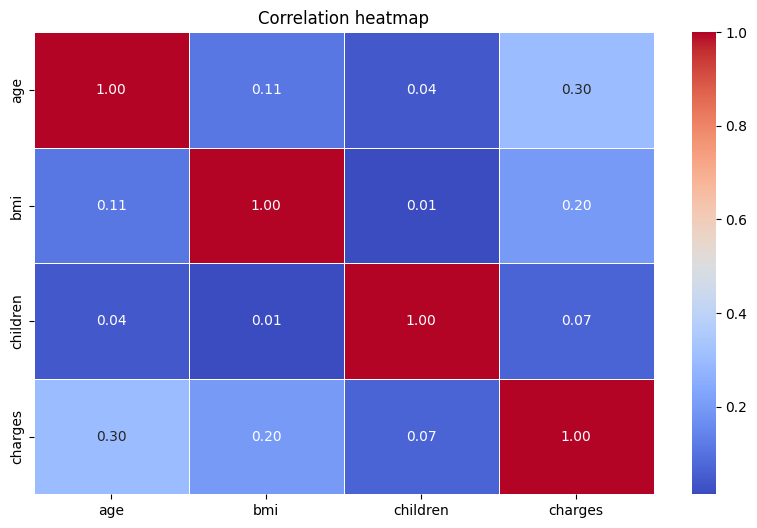

In [88]:
num_cols = ['age', 'bmi', 'children']
corr_matrix = insurance[num_cols + [target]].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm",fmt=".2f", linewidths=0.5)
plt.title('Correlation heatmap')
plt.show()

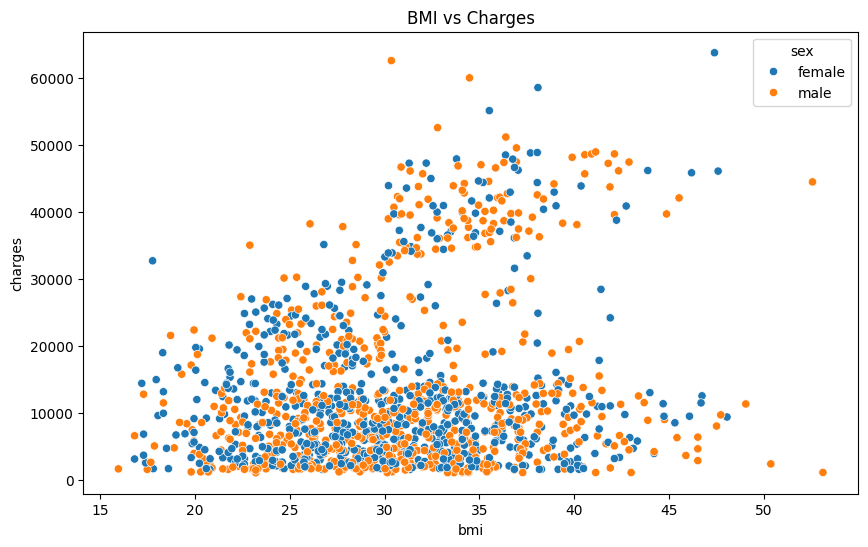

In [89]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='bmi', y=target, data=insurance, hue='sex')
plt.title('BMI vs Charges')
plt.show()

## TODO A3: Feature Preparation (5 Marks)
**You must:**
- Train-test split
- Scaling (if applicable)

**Marks:** Correct split (3), Explanation (2)


In [90]:
X = insurance.drop('charges', axis=1)
y = insurance['charges']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.20, random_state=42)

## TODO A4: Multiple Linear Regression (8 Marks)
**You must:**
- Train model
- Evaluate using RMSE, MAE, R²

**Marks:** Model (4), Metrics (4)


In [91]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print('RMSE: ', rmse)
print('MAE: ', mae)
print('R^2 Score: ', r2)

RMSE:  5796.284659276274
MAE:  4181.194473753651
R^2 Score:  0.7835929767120722


## TODO A5: Polynomial Regression (7 Marks)
**You must:**
- Apply polynomial features
- Compare with linear regression

**Marks:** Implementation (4), Comparison (3)


In [92]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)
y_pred_poly = poly_reg.predict(X_test_poly)

mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)

mae_poly = mean_absolute_error(y_test, y_pred_poly)

r2_poly = r2_score(y_test, y_pred_poly)

print('RMSE: ', rmse_poly)
print('MAE: ', mae_poly)
print('R^2 Score: ', r2_poly)

RMSE:  4551.132385233192
MAE:  2729.500133639456
R^2 Score:  0.8665830903164841


The Polynomial Regression model performed better. It gave lower RMSE and MAE and Higer R2. Thus, we can say that polynomial explains more of the variation in charges and make more acccurate prediction.

## TODO A6: Support Vector Regression (7 Marks)
**You must:**
- Train SVR (RBF kernel)
- Evaluate performance
- Justify kernel choice

**Marks:** Model (4), Justification (3)


In [93]:
svr = SVR(kernel='rbf', C=100, gamma=.1, epsilon=1.0)
svr.fit(X_train, y_train)

y_pred = svr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print('RMSE: ', rmse)
print('MAE: ', mae)
print('R^2 Score: ', r2)

RMSE:  10647.900190000875
MAE:  5695.147782825441
R^2 Score:  0.269702384252792


I choose the RBF kernel because it can model non linear regression between features and target variable.

## TODO A7: Random Forest Regressor (8 Marks)
**You must:**
- Train Random Forest
- Evaluate model

**Marks:** Model (4), Evaluation (4)


In [94]:
rf = RandomForestRegressor(
    n_estimators = 100,
    random_state = 42,
    max_depth=None,
    n_jobs =1
)

rf.fit(X_train,y_train)

y_pred = rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print('RMSE: ', rmse)
print('MAE: ', mae)
print('R^2 Score: ', r2)

RMSE:  4567.775116331386
MAE:  2543.9758251029275
R^2 Score:  0.8656055394920775


# 🟠 PART B: Classification Task (45 Marks)
You will work with the provided **classification dataset**.


## TODO B1: Dataset Understanding (5 Marks)
**You must:**
- Load dataset
- Show class distribution
- Comment on imbalance

**Marks:** Analysis (3), Explanation (2)


In [95]:
df_loan = pd.read_csv('/content/sample_data/loan_data.csv')

df_loan.head(10)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
5,21.0,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,No,1
6,26.0,female,Bachelor,93471.0,1,RENT,35000.0,EDUCATION,12.42,0.37,3.0,701,No,1
7,24.0,female,High School,95550.0,5,RENT,35000.0,MEDICAL,11.11,0.37,4.0,585,No,1
8,24.0,female,Associate,100684.0,3,RENT,35000.0,PERSONAL,8.90,0.35,2.0,544,No,1
9,21.0,female,High School,12739.0,0,OWN,1600.0,VENTURE,14.74,0.13,3.0,640,No,1


In [96]:
df_loan.shape

(45000, 14)

In [97]:
df_loan.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,45000.0,27.764178,6.045108,20.00,24.00,26.00,30.00,144.00
person_income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
credit_score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00
loan_status,45000.0,0.222222,0.415744,0.00,0.00,0.00,0.00,1.00


In [98]:
class_counts = df_loan['loan_status'].value_counts()
print('Class Distribution: ', class_counts)

Class Distribution:  loan_status
0    35000
1    10000
Name: count, dtype: int64


## TODO B2: Exploratory Data Analysis (5 Marks)
**You must:**
- Plot class counts
- Plot at least one feature vs class

**Marks:** Plots (5),


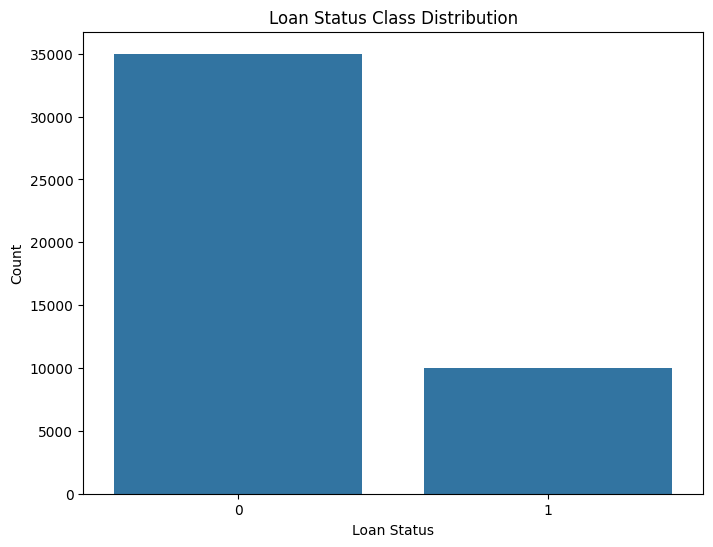

In [99]:
plt.figure(figsize=(8,6))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Loan Status Class Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

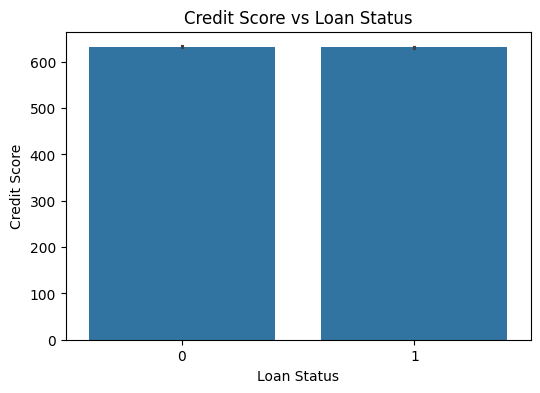

In [100]:
plt.figure(figsize=(6,4))
sns.barplot(x='loan_status', y='credit_score', data=df_loan)
plt.title('Credit Score vs Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Credit Score')
plt.show()

## TODO B3: Feature Preparation (5 Marks)
**You must:**
- Encoding (if needed)
- Scaling
- Train-test split with stratification




In [103]:
categorical_cols = ["person_gender", "person_education", "person_home_ownership", "loan_intent", "previous_loan_defaults_on_file"]
label_encoders = {}
for col in categorical_cols:
  le = LabelEncoder()
  df_loan[col] = le.fit_transform(df_loan[col])
  label_encoders[col] =  le

In [107]:
numeric_cols = ["person_age", "person_income", "person_emp_exp", "loan_amnt", "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length", "credit_score"]

scaler = StandardScaler()
df_loan[numeric_cols] = scaler.fit_transform(df_loan[numeric_cols])

X = df_loan.drop('loan_status', axis=1)
y = df_loan['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20, random_state=42, stratify=y)

print('Training Sample: ', X_train.shape)
print('Test Sample: ', X_test.shape)

Training Sample:  (36000, 13)
Test Sample:  (9000, 13)


## TODO B4: Logistic Regression with L2 (8 Marks)
**You must:**
- Train Logistic Regression
- Evaluate using Accuracy, Precision, Recall
- Show Confusion Matrix

**Marks:** Model (4), Metrics (4)


In [109]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logi_reg = LogisticRegression(max_iter=100)
logi_reg.fit(X_train_scaled, y_train)

y_pred = logi_reg.predict(X_test_scaled)

print('Test Accuracy: ', accuracy_score(y_test,y_pred))

Test Accuracy:  0.8967777777777778


In [110]:
print('Classification Report:\n', classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.93      7000
           1       0.78      0.75      0.76      2000

    accuracy                           0.90      9000
   macro avg       0.85      0.84      0.85      9000
weighted avg       0.90      0.90      0.90      9000



Confusion Matrix: 
 [[6572  428]
 [ 501 1499]]


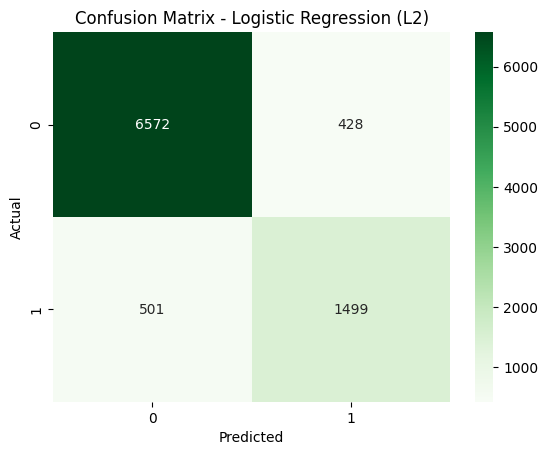

In [111]:
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix: \n', cm)

sns.heatmap(cm, annot=True, fmt='d', cmap="Greens", xticklabels=[0,1], yticklabels=[0,1])
plt.title("Confusion Matrix - Logistic Regression (L2)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



## TODO B5: Support Vector Machine (7 Marks)
**You must:**
- Train SVM (Linear or RBF)
- Evaluate

**Marks:** Model (4), Evaluation (3)


In [113]:
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_clf.fit(X_train_scaled, y_train)

y_pred = svm_clf.predict(X_test_scaled)

In [114]:
print('Test Accuracy: ', accuracy_score(y_test,y_pred))

Test Accuracy:  0.9088888888888889


In [115]:
print('Classification Report:\n', classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.94      7000
           1       0.83      0.75      0.78      2000

    accuracy                           0.91      9000
   macro avg       0.88      0.85      0.86      9000
weighted avg       0.91      0.91      0.91      9000



Confusion Matrix: 
 [[6686  314]
 [ 506 1494]]


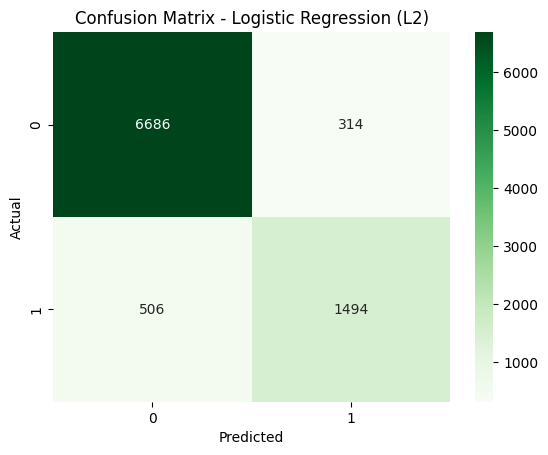

In [116]:
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix: \n', cm)

sns.heatmap(cm, annot=True, fmt='d', cmap="Greens", xticklabels=[0,1], yticklabels=[0,1])
plt.title("Confusion Matrix - Logistic Regression (L2)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## TODO B6: Naive Bayes (5 Marks)
**You must:**
- Choose correct NB variant



In [118]:
gnb_clf = GaussianNB()
gnb_clf.fit(X_train_scaled,y_train)

y_pred = gnb_clf.predict(X_test_scaled)

In [120]:
print('Test Accuracy: ', accuracy_score(y_test,y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))

Test Accuracy:  0.7363333333333333
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.66      0.80      7000
           1       0.46      1.00      0.63      2000

    accuracy                           0.74      9000
   macro avg       0.73      0.83      0.71      9000
weighted avg       0.88      0.74      0.76      9000



Confusion Matrix: 
 [[4630 2370]
 [   3 1997]]


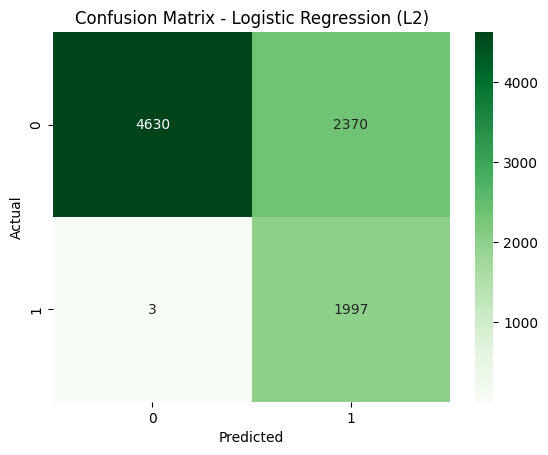

In [121]:
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix: \n', cm)

sns.heatmap(cm, annot=True, fmt='d', cmap="Greens", xticklabels=[0,1], yticklabels=[0,1])
plt.title("Confusion Matrix - Logistic Regression (L2)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## TODO B7: K-Nearest Neighbors (5 Marks)
**You must:**
- Try multiple K values
- Plot accuracy vs K

**Marks:** Experiment (3), Plot & choice (2)


In [127]:
k_values = range(5,71)
acc = []

for k in k_values:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(X_train_scaled,y_train)
    pred = model.predict(X_test_scaled)
    acc.append(accuracy_score(y_test,pred))

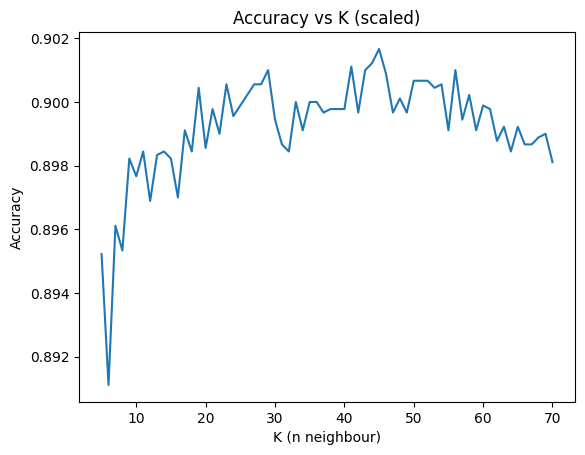

In [128]:
plt.figure()
plt.plot(list(k_values),acc)
plt.xlabel('K (n neighbour)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs K (scaled)')
plt.show()

In [129]:
best_k = list(k_values)[int(np.argmax(acc))]
print('Best K: ', best_k)
print('Best Accuracy: ', float(np.max(acc)))

Best K:  45
Best Accuracy:  0.9016666666666666


## TODO B8: Random Forest Classifier (5 Marks)
**You must:**
- Train model
- Show feature importance

**Marks:** Model (3), Interpretation (2)


In [130]:
rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_clf.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [131]:
y_pred = rf_clf.predict(X_test_scaled)

print('Test Accuracy: ', accuracy_score(y_test,y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))

Test Accuracy:  0.927
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.95      7000
           1       0.89      0.77      0.82      2000

    accuracy                           0.93      9000
   macro avg       0.91      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000



In [133]:
imp = pd.Series(
    rf_clf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

imp.head(10)

,0
previous_loan_defaults_on_file,0.220677
loan_percent_income,0.162804
loan_int_rate,0.160318
person_income,0.129435
person_home_ownership,0.066664
loan_amnt,0.060769
credit_score,0.056137
loan_intent,0.035536
person_age,0.030057
person_emp_exp,0.027044


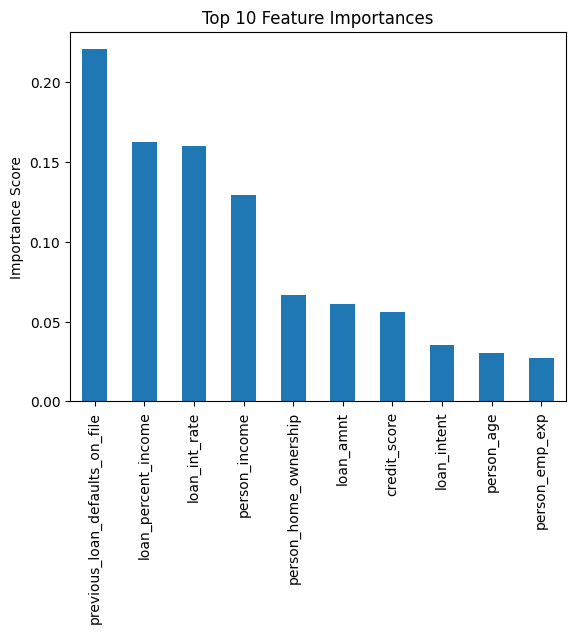

In [134]:
plt.figure()
imp.head(10).plot(kind='bar')
plt.title('Top 10 Feature Importances')
plt.ylabel('Importance Score')
plt.show()

# 🧠 Final Reflection (5 Marks)
**Answer briefly:**
- Best regression model and why
- Best classification model and why
- One real-world deployment scenario


1. Best regression model: Polynomial Regression and Random Forest acieved almost similar performance. R2 score is: 86.6%. But Polynomial Regression had slightly lower RMSE while Random Forest had lower MAE. Overall, I think Random Forest will be more practical for deployment.
2. Best classification model: I think Random Forest is the best classification model among the all models tested. It gives the highest accuracy. This is because it handles complex, non linear relationships in the load dataset and reduces overfitting through ensemble averaging.
3. One real-world deployment scenario: The loan approval model could be used in a bank's credit system. When people apply for loans, the model quickly check the information and give a score. If the model finds someone is high risk, the bank staff can review the case more carefully.